In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# --!--------------------------------------------------------------------------
# --! prepare a dataset

# --! define known data properties
timeseries_len  = 200
timestep        = 0.001
dataset_dir     = 'cavity/train_global'
x_len           = 200 # 40 * 5

# --! read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

# --! data channels are expected to contain:
# --! 1. displacement
x_dims_n = 1

# --! compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# --! print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1


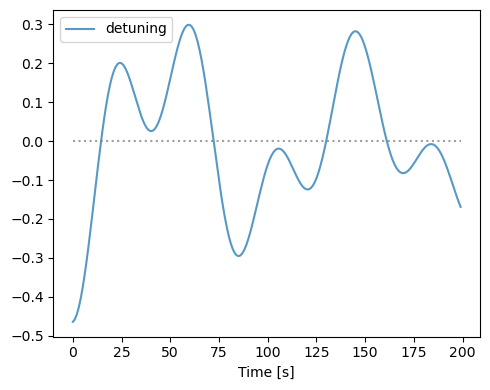

In [3]:
data_i = 5
data_viz = data_train[data_i]
t_viz = torch.linspace(0., timestep*timeseries_len, timeseries_len)
zero_viz = torch.zeros_like(t_viz)

plt.figure(figsize=(5, 4))
plt.plot(data_viz[:, 0], color='tab:blue', alpha=0.75, label='detuning')
plt.plot(zero_viz, color='tab:gray', linestyle='dotted', alpha=0.75)
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [4]:
# --!--------------------------------------------------------------------------
# --! load a model trained for embedding representation

# --! ensure reproducible results
seed = 15
torch.manual_seed(seed)

model = torch.load('data/models/care_embedding.pt', weights_only=False)

inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


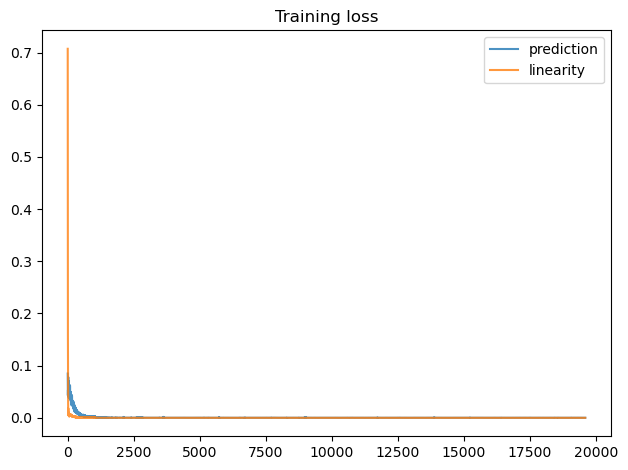

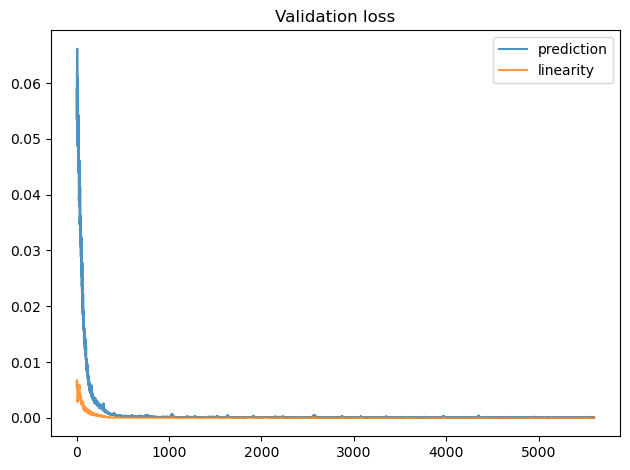

inf >> prediction loss in training is 8.618601e-04
inf >> linearity loss in training is 2.774355e-04


In [5]:
# --!--------------------------------------------------------------------------
# --! training and validation of the global Koopman operator

# --! we train the global operator here, so freeze everything else
#utils.freeze_module(model.fun_params_kern_enc)
#utils.freeze_module(model.dec)
utils.freeze_module(model.funs_dyn_enc)
utils.freeze_module(model.funs_dyn)
utils.unfreeze_module(model.timeseries_dyn)

bat_sz = 128

# --! specify optimizer
optimizer = torch.optim.Adam(
    filter(lambda param: param.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=1e-8)

# --! empty arrays to gather metrics
loss_train_pred  = []
loss_train_lin   = []
loss_valid_pred  = []
loss_valid_lin   = []

# --! training duration
datafiles_train_n = 7
epochs_n          = 100
print(f"inf >> Number of data files for training : {datafiles_train_n}")

# --! prepare validation dataset
dataset_valid = torch.utils.data.TensorDataset(data_valid)

for datafile_train in range(datafiles_train_n):
    print(f"inf >> processing training file number {datafile_train + 1}")

    # --! make training datasets and loaders
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=bat_sz, shuffle=True)

    # --! train
    for epoch in range(epochs_n):

        # --! train neural networks
        for this, data in enumerate(dataloader_train):
            x = data[0][:, :x_len, :1]

            optimizer.zero_grad()

            # --! fit a model to training data
            loss, _, loss_pred, loss_lin = model.fit(x, global_only=True)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                loss_train_pred.append(loss_pred)
                loss_train_lin.append(loss_lin)

        # --! validate results
        with torch.no_grad():
            dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=bat_sz, shuffle=False)
            for data in dataloader_valid:
                x  = data[0][:, :x_len, :1] # take only displacement

                # --! validate prediction
                outs = model(x, global_only=True)
                loss_valid_pred.append(torch.mean((x - outs[3])**2))
                loss_valid_lin.append(torch.mean((outs[0] - outs[1])**2))

# --!# display training statistics
with torch.no_grad():
    plt.figure()
    plt.title('Training loss')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.title('Validation loss')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    loss_train_pred_mean = np.mean(loss_train_pred)
    loss_train_lin_mean = np.mean(loss_train_lin)
    print(f'inf >> prediction loss in training is {loss_train_pred_mean:e}')
    print(f'inf >> linearity loss in training is {loss_train_lin_mean:e}')

In [6]:
# --!--------------------------------------------------------------------------
# --! gather test metrics

with torch.no_grad():
    # --! make validation datasets and loaders
    dataset_test = torch.utils.data.TensorDataset(data_test)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=bat_sz, shuffle=False)

    loss_test_pred = []

    for data in dataloader_test:
        x  = data[0][:, :x_len, :x_dims_n]

        outs = model(x, global_only=True)
        loss_test_pred.append(torch.mean((x - outs[3])**2))

    loss_test_pred_mean = np.mean(loss_test_pred)
    print(f'inf >> prediction loss in test is {loss_test_pred_mean:e}') # 9.909760e-05

inf >> prediction loss in test is 1.046164e-04


tensor([-0.7092+0.5074j, -0.7092-0.5074j,  0.8342+0.1853j,  0.8342-0.1853j])
tensor([[-0.0222+0.4326j, -0.0222-0.4326j, -0.0046-0.0098j, -0.0046+0.0098j],
        [-0.7788+0.0000j, -0.7788-0.0000j, -0.1328+0.3328j, -0.1328-0.3328j],
        [-0.1205-0.1589j, -0.1205+0.1589j, -0.7441+0.0000j, -0.7441-0.0000j],
        [-0.4060-0.0361j, -0.4060+0.0361j,  0.0436-0.5620j,  0.0436+0.5620j]])


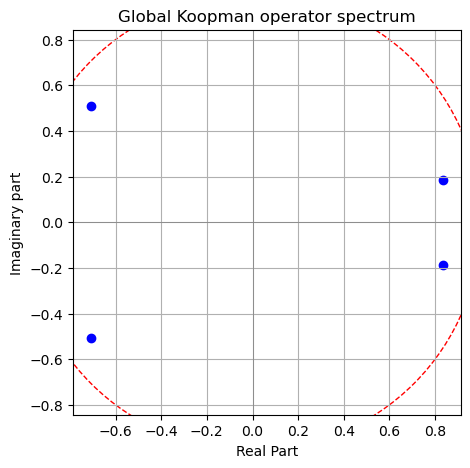

In [7]:
# --!--------------------------------------------------------------------------
# --! visualize global operator eigenvalues

with torch.no_grad():
    eigvals, eigvecs = torch.linalg.eig(model.timeseries_dyn.weight)
    print(eigvals)
    print(eigvecs)

    plt.figure(figsize=(5, 5))
    plt.scatter(eigvals.real, eigvals.imag, c='blue')
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    circle = plt.Circle((0, 0), 1, color='r', fill=False, linestyle='--')
    plt.gca().add_artist(circle)
    plt.title("Global Koopman operator spectrum")
    plt.xlabel("Real Part")
    plt.ylabel("Imaginary part")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

tensor([[0.0722],
        [0.0722],
        [0.1402],
        [0.1402]])
[[1.]
 [2.]
 [3.]
 [4.]]


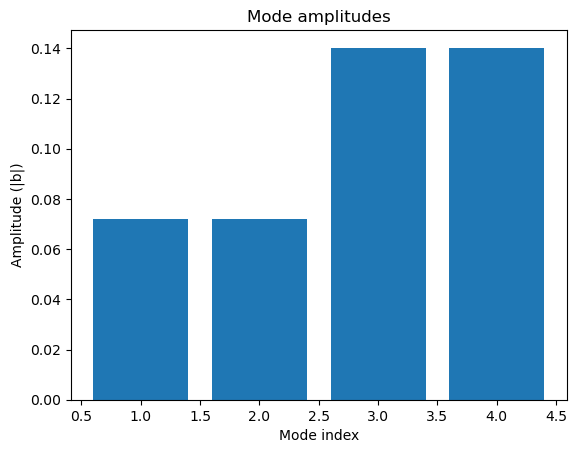

In [36]:
# --!--------------------------------------------------------------------------
# --! analyze the amplitude of global operator eigenvalues

save_eigamps = False

with torch.no_grad():
    data_i      = 125
    data_ic     = torch.unsqueeze(data_test[data_i][:model.fun_params_kern_sz, :1], 0)
    funs_ic     = model._embed_functions(data_ic)
    eigvecs_inv = torch.linalg.inv(eigvecs)
    funs_ic     = torch.squeeze(funs_ic, 0)
    eigvecs_inv = torch.squeeze(eigvecs_inv, 0)
    funs_ic     = funs_ic.to(torch.cfloat)
    b = torch.matmul(eigvecs_inv, torch.transpose(funs_ic, 0, 1))
    b = b.abs()
    b_nums = np.array([range(len(b[:, 0]))]).reshape(-1, 1) + 1.0
    print(b)
    print(b_nums)

    plt.figure()
    plt.bar(b_nums[:, 0], b[:, 0])
    plt.title("Mode amplitudes")
    plt.xlabel("Mode index")
    plt.ylabel("Amplitude (|b|)")
    plt.show()

    if save_eigamps:
        eigamps = np.expand_dims(np.concatenate([b_nums, b], axis=1), 0)
        utils.write_datafile(f'global_eigamps_{data_i}', eigamps, delim=' ')


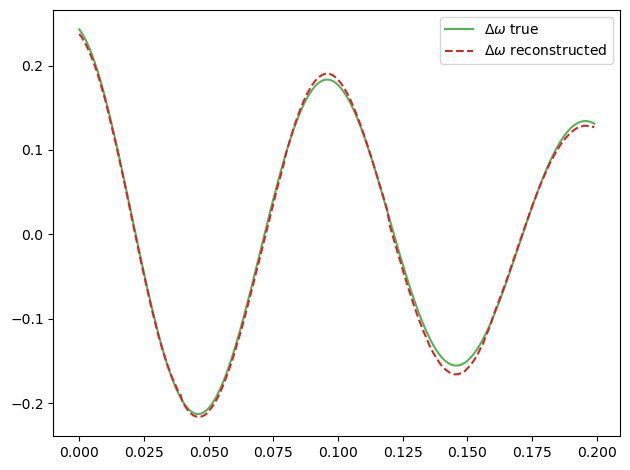

In [16]:
# --!--------------------------------------------------------------------------
# --! sanity check that reconstruction still works

save_sigs = True

with torch.no_grad():
    data_i  = 123
    data    = data_test[data_i]

    timeseries = torch.unsqueeze(data[:x_len, :1], dim=0)
    timeseries_recon = model.dec(model._embed_functions(timeseries))
    timeseries_recon = timeseries_recon.reshape(timeseries_recon.shape[0], -1, model.feats_n)

    timeseries = torch.squeeze(timeseries, 0)
    timeseries_recon = torch.squeeze(timeseries_recon, 0)

    t = np.arange(0., x_len*timestep, timestep)

    plt.figure()
    plt.plot(t, timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
    plt.plot(t, timeseries_recon[:, 0], alpha=1, color='tab:red', linestyle='dashed', label='$\\Delta \\omega$ reconstructed')
    plt.legend()
    plt.tight_layout()
    plt.show()

    if save_sigs:
        sigs = np.expand_dims(np.concatenate([t, timeseries, timeseries_pred], axis=1), 0)
        utils.write_datafile(f'global_sig_{data_i}', sigs, delim=' ')

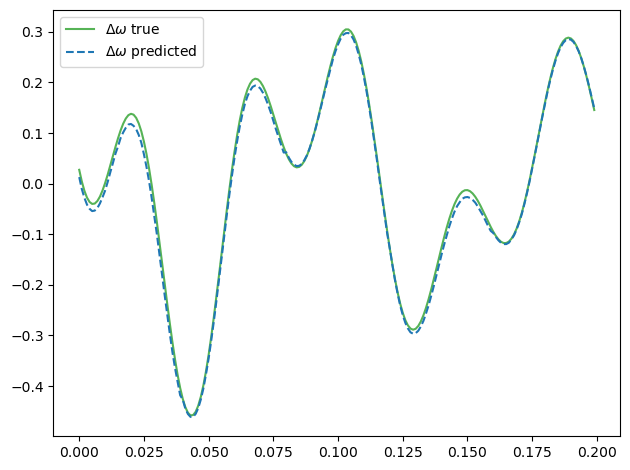

In [25]:
# --!--------------------------------------------------------------------------
# --! test individual results

save_sigs = False

with torch.no_grad():
    data_i  = 125
    data    = data_test[data_i]

    timeseries = torch.unsqueeze(data[:x_len, :1], dim=0)
    funs, funs_pred, _, timeseries_pred = model(timeseries, global_only=True)

    timeseries = torch.squeeze(timeseries, dim=0)
    timeseries_pred = torch.squeeze(timeseries_pred, dim=0)

    t = np.arange(0., x_len*timestep, timestep).reshape(-1, 1)

    plt.figure()
    plt.plot(t[:, 0], timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
    plt.plot(t[:, 0], timeseries_pred[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ predicted')
    plt.legend()
    plt.tight_layout()
    plt.show()

    if save_sigs:
        sigs = np.expand_dims(np.concatenate([t, timeseries, timeseries_pred], axis=1), 0)
        utils.write_datafile(f'global_sig_{data_i}', sigs, delim=' ')

In [11]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = True

if savemod_on:
    torch.save(model, 'data/models/care_global.pt')

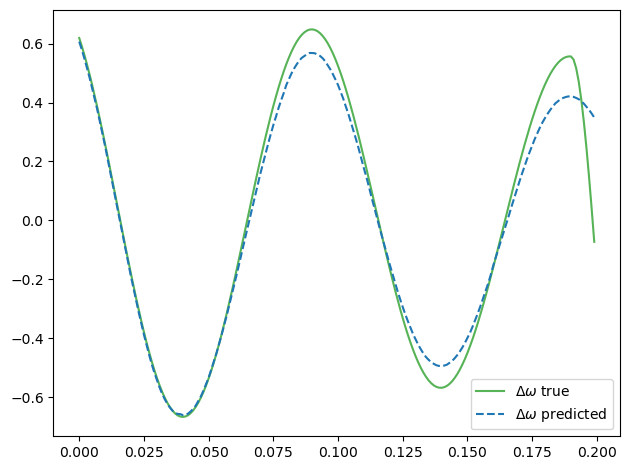

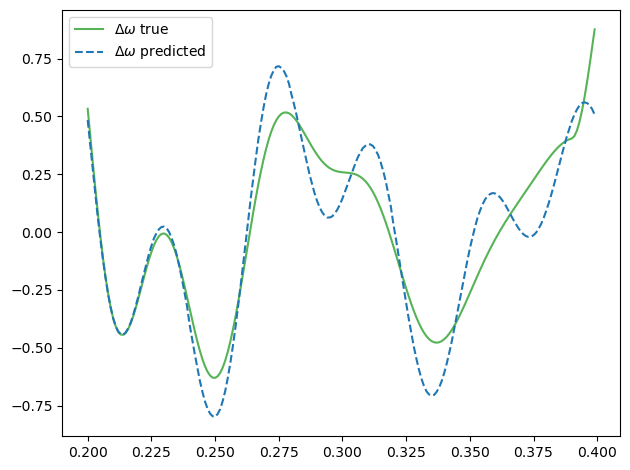

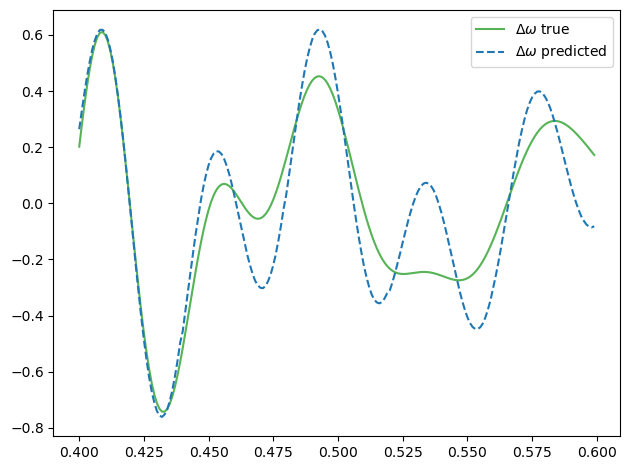

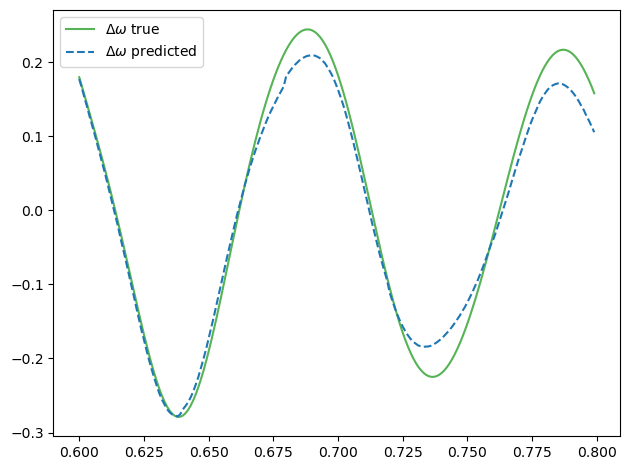

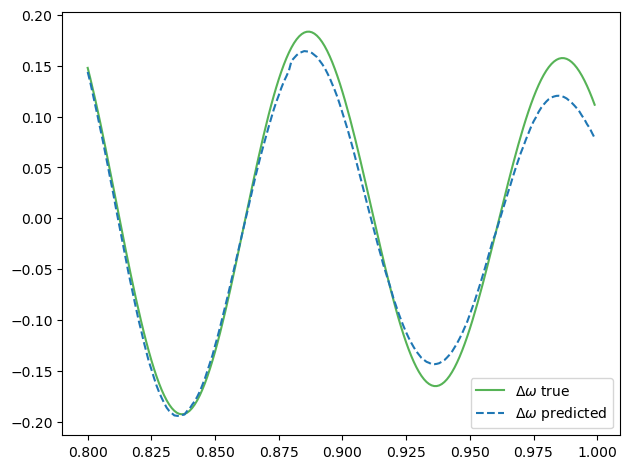

In [39]:
# --!--------------------------------------------------------------------------
# --! evaluate model on long timeseries

eval_ts_len       = 200
eval_timestep     = 0.001
eval_dataset_dir  = 'cavity/eval_10Hz_24Hz'

eval_data = utils.read_datafile(f'{eval_dataset_dir}/eval1', eval_ts_len)

save_sigs_trans = True

with torch.no_grad():
    data = torch.split(eval_data, 1, dim=0)
    for this, datum in enumerate(data):
        datum = datum[:, :x_len, :1]
        outs = model(datum, global_only=True)

        timeseries = torch.squeeze(datum, dim=0)
        timeseries_pred = torch.squeeze(outs[3], dim=0)

        t = np.arange(0., eval_ts_len*eval_timestep, eval_timestep).reshape(-1, 1)
        t = t + this*0.2

        plt.figure()
        plt.plot(t[:x_len, 0], timeseries[:x_len, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
        plt.plot(t[:x_len, 0], timeseries_pred[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ predicted')
        plt.legend()
        plt.tight_layout()
        plt.show()

        if save_sigs_trans:
            sig_trans = np.expand_dims(np.concatenate([t[:x_len, :1], timeseries, timeseries_pred], axis=1), 0)
            utils.write_datafile(f'global_sig_trans_{this}', sig_trans, delim=' ')